In [69]:
import numpy as np 
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import scipy.linalg
import scipy.spatial
import sympy
from sympy.utilities.lambdify import lambdify

# Introduction to numerical methods

János Török

# Class 5: Derivation

# Differentiation in Python: Symbolic, Numerical and Automatic

## Symbolic Differentiation

Though not used by extremely many, it is worth looking at symbolic calculations

### Symbolic Computation with `SymPy`
One can define variables as symbols:

In [2]:
s = "x y"
x,y = sympy.symbols(s)
print(type(x))

<class 'sympy.core.symbol.Symbol'>


In [3]:
2*x+3

2*x + 3

### Numerical value

In [4]:
(2*x+3).evalf(subs={x:2})

7.00000000000000

### Derivation

In [5]:
sympy.diff(x**3-2*x**2,x)

3*x**2 - 4*x

In [6]:
sympy.diff(x**4-2*x**2,x).evalf(subs={x:2})

24.0000000000000

### Create a `numpy` function out of it

In [7]:
df = lambdify(x, sympy.diff(x**4-2*x**2,x), 'numpy')

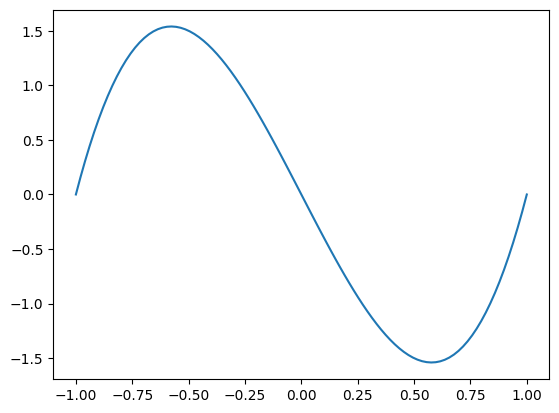

In [8]:
xa = np.linspace(-1,1,100)
plt.plot(xa,df(xa));

In [9]:
sympy.diff(sympy.sin((3*(x+1))**2))

(18*x + 18)*cos((3*x + 3)**2)

## RPN: Reverse Polish Notation

<b>This part is for general information and no test questions will be asked about the RPN notation and the Shunting yard algorithm!</b>

Let us spend sime time on how one can evaluate a symbolic expression. How can you evaluate an expression like the previous one, where you have parantheses and strict order of operators. The first question is if we can rewrite the formula which can be evaluated in a continuous manner, namely that the algorithm do not require chacking back and forth? The ansert is RPN.

## RPN: description
The operators always follow their operands. A small example ($\wedge$ is the power operator):
$$\begin{align*}
1+2 \qquad&\to\qquad 1~2~+\\
1+2*3 \qquad&\to\qquad 2~3~*~1~+\\
1*(2+3) \qquad&\to\qquad 1~2~3~+~*\\
\sin\left((3*(x+1))^2\right)\qquad&\to\qquad 3~x~1~+~*~2~\wedge~\sin
\end{align*}
$$

## RPN: evaluation
We have an ordered list of objects which can be: <b>numbers</b>, <b>variables</b>, <b>unary</b>, <b>binary operators</b>, etc. We prepare a stack, which is a LiFo (Last in First out) object and can stor elements when an element is removed it is always the most recently added one (LiFo). The list is processes sequentially based on the type the following steps are taken:
 1. <b>numbers</b>: add the number to the stack
 2. <b>variable</b>: evaluate the variable and add the resultin number to the stack
 3. <b>unary operator</b>: take the last element from the stack and apply the unary operator to it then push the result back to the stack
 4. <b>binary operator</b>: (also works with higher order operators), take the last two elements from the stack, execute the operator and puch back the result to the stack

Let us see the examples:

$$ 1+2 \qquad\to\qquad 1~2~+$$
$$
\begin{array}{|l|l|l|}
\hline
\mathbf{index} & \mathbf{RPN} & \mathbf{Stack}\cr
\hline
0 &  \mathbf{1}~2~+ & 1\cr
\hline
1 &  1~\mathbf{2}~+ & 1,2\cr
\hline
2 &  1~2~\mathbf{+} & 3\cr
\hline
\end{array}
$$

$$1+2*3 \qquad\to\qquad 2~3~*~1~+$$
$$
\begin{array}{|l|l|l|}
\hline
\mathbf{index} & \mathbf{RPN} & \mathbf{Stack}\cr
\hline
0 &  \mathbf{2}~3~*~1~+ & 2\cr
\hline
1 &  2~\mathbf{3}~*~1~+  & 2,3\cr
\hline
2 &  2~3~\mathbf{*}~1~+  & 6\cr
\hline
3 &  2~3~*~\mathbf{1}~+  & 6,1\cr
\hline
4 &  2~3~*~1~\mathbf{+}  & 7\cr
\hline
\end{array}
$$

$$1*(2+3) \qquad\to\qquad 1~2~3~+~*$$
$$
\begin{array}{|l|l|l|}
\hline
\mathbf{index} & \mathbf{RPN} & \mathbf{Stack}\cr
\hline
0 &  \mathbf{1}~2~3~+~* & 1\cr
\hline
1 &  1~\mathbf{2}~3~+~*  & 1,2\cr
\hline
2 &  1~2~\mathbf{3}~+~*  & 1,2,3\cr
\hline
3 &  1~2~3~\mathbf{+}~*  & 1,5\cr
\hline
4 &  1~2~3~+~\mathbf{*}  & 5\cr
\hline
\end{array}
$$

$$\sin\left([3*(x+1)]^2\right)\qquad\to\qquad 3~x~1~+~*~2~\wedge~\sin$$

We have to set the value of $x$. Let it be $x=2$.
$$
\begin{array}{|l|l|l|}
\hline
\mathbf{index} & \mathbf{RPN} & \mathbf{Stack}\cr
\hline
0 &  \mathbf{3}~x~1~+~*~2~\wedge~\sin & 3\cr
\hline
1 &  3~\mathbf{x}~1~+~*~2~\wedge~\sin & 3,2\cr
\hline
2 &  3~x~\mathbf{1}~+~*~2~\wedge~\sin & 3,2,1\cr
\hline
3 &  3~x~1~\mathbf{+}~*~2~\wedge~\sin & 3,3\cr
\hline
4 &  3~x~1~+~\mathbf{*}~2~\wedge~\sin & 9\cr
\hline
5 &  3~x~1~+~*~\mathbf{2}~\wedge~\sin & 9,2\cr
\hline
6 &  3~x~1~+~*~2~\mathbf{\wedge}~\sin & 81\cr
\hline
7 &  3~x~1~+~*~2~\wedge~\mathbf{sin} & -0.63\cr
\hline
\end{array}
$$

## RPN: Encoding, the Shunting yard algorithm
Example from Wikipedia: $A+B*C-D$

<img src="Shunting_yard.png">


The input is processed one symbol at a time:
 * If a variable or number is found, it is copied directly to the output a), c), e), h).
 * If the symbol is an operator, it is pushed onto the operator stack b), d), f).
   - If the operator's precedence is lower than that of the operators at the top of the stack
   - If the precedences are equal and the operator is left associative, then that operator is popped off the stack and added to the output g)
 * Finally, any remaining operators are popped off the stack and added to the output i).

$$\sin\left([3*(x+1)]^2\right)$$

Order of the operations: 
 1. $+,-$
 2. $*,/$
 3. $\wedge$
 4. unitary
 5. $(+.-)$
 6. $(*,/)$
 7. $(\wedge)$
 8. unitary
 9. $((+,-))$
 10. etc.
$$
\begin{array}{|l|l|l|}
\hline
\mathbf{Input}& \mathbf{Paranthesis} & \mathbf{Operation~stack(precedence)}  &\mathbf{Output}\cr
\hline
\sin\left([3*(x+1)]\wedge2\right) & 0&  & \cr
\hline
([3*(x+1)]\wedge2) & 0&\sin(4)  & \cr
\hline
[3*(x+1)]\wedge2) & 1&\sin(4)  & \cr
\hline
3*(x+1)]\wedge2) & 2&\sin(4)  & \cr
\hline
*(x+1)]\wedge2) & 2&\sin(4)  & 3\cr
\hline
(x+1)]\wedge2) & 2&\sin(4),*(10)  & 3\cr
\hline
x+1)]\wedge2) & 3&\sin(4),*(10)  & 3\cr
\hline
+1)]\wedge2) & 3&\sin(4),*(10)  & 3,x\cr
\hline
1)]\wedge2) & 3&\sin(4),*(10),+(13)  & 3,x\cr
\hline
)]\wedge2) & 3&\sin(4),*(10),+(13)  & 3,x,1\cr
\hline
]\wedge2) & 2&\sin(4),*(10),+(13)  & 3,x,1\cr
\hline
\wedge2) & 1&\sin(4),*(10),+(13)  & 3,x,1\cr
\hline
2) & 1&\sin(4),\wedge(7) & 3,x,1,+,*\cr
\hline
) & 1&\sin(4),\wedge(7) & 3,x,1,+,*,2\cr
\hline
 & 0& & 3,x,1,+,*,2,\wedge,\sin\cr
\hline
\end{array}
$$

## Derivation?
 * Do it in infix notation
 * In increasing order of operator precedence
 * Implement the formula and recursively call derivation to sub parts, as you would do normally

$$
\begin{align*}
\frac{d}{dx}\sin\left([3*(x+1)]\wedge2\right)&=\cos\left([3*(x+1)]\wedge2\right) * \left([3*(x+1)]\wedge2\right)'=\cr
&=\cos\left([3*(x+1)]\wedge2\right) * 2* [3*(x+1)]*[3*(x+1)]'=\cr
&=\cos(\dots)*2*[3*(x+1)]*[3'*(x+1)+3*(x+1)']=\cr
&=\cos(\dots)*2*[3*(x+1)]*[0*(x+1)+3*(1+0)]
\end{align*}$$

## Numerical derivation

# Finite Difference Approximating Derivatives

The derivative $f'(x)$ of a function $f(x)$ at the point $x=a$ is defined as:

$$f'(a) = \lim\limits_{x \to a}\frac{f(x) - f(a)}{x-a}$$

The derivative at $x=a$ is the slope at this point. In **finite difference** approximations of this slope, we can use values of the function in the neighborhood of the point $x=a$ to achieve the goal. There are various finite difference formulas used in different applications, and three of these, where the derivative is calculated using the values of two points, are presented below. 

The **forward difference** is to estimate the slope of the function at $x_j$ using the line that connects $(x_j, f(x_j))$ and $(x_{j+1}, f(x_{j+1}))$:

$$f'(x_j) = \frac{f(x_{j+1}) - f(x_j)}{x_{j+1}-x_j}$$

The **backward difference** is to estimate the slope of the function at $x_j$ using the line that connects $(x_{j-1}, f(x_{j-1}))$ and $(x_j, f(x_j))$:

$$f'(x_j) = \frac{f(x_j) - f(x_{j-1})}{x_j - x_{j-1}}$$

The **central difference** is to estimate the slope of the function at $x_j$ using the line that connects $(x_{j-1}, f(x_{j-1}))$ and $(x_{j+1}, f(x_{j+1}))$:

$$f'(x_j) = \frac{f(x_{j+1}) - f(x_{j-1})}{x_{j+1} - x_{j-1}}$$

The following figure illustrates the three different type of formulas to estimate the slope. 

<img src="20.02.01-Finite-difference.png" alt="Finite difference" title="Finite difference approximation of the derivative." width="800"/>

## Finite Difference Approximating Derivatives with Taylor Series

To derive an approximation for the derivative of $f$, we return to Taylor series. For an arbitrary function $f(x)$ the Taylor series of $f$ around $a = x_j$ is
$$
f(x) = \frac{f(x_j)(x - x_j)^0}{0!} + \frac{f^{\prime}(x_j)(x - x_j)^1}{1!} + \frac{f''(x_j)(x - x_j)^2}{2!} + \frac{f'''(x_j)(x - x_j)^3}{3!} + \cdots.
$$

If $x$ is on a grid of points with spacing $h$, we can compute the Taylor series at $x = x_{j+1}$ to get

$$
f(x_{j+1}) = \frac{f(x_j)(x_{j+1} - x_j)^0}{0!} + \frac{f^{\prime}(x_j)(x_{j+1}- x_j)^1}{1!} + \frac{f''(x_j)(x_{j+1} - x_j)^2}{2!} + \frac{f'''(x_j)(x_{j+1} - x_j)^3}{3!} + \cdots.
$$

Substituting $h = x_{j+1} - x_j$ and solving for $f^{\prime}(x_j)$ gives the equation

$$
f^{\prime}(x_j) = \frac{f(x_{j+1}) - f(x_j)}{h} + \left(-\frac{f''(x_j)h}{2!} -\frac{f'''(x_j)h^2}{3!} - \cdots\right).
$$

The terms that are in parentheses, $-\frac{f''(x_j)h}{2!} -\frac{f'''(x_j)h^2}{3!} - \cdots$, are called **higher order terms** of $h$. The higher order terms can be rewritten as

$$
-\frac{f''(x_j)h}{2!} -\frac{f'''(x_j)h^2}{3!} - \cdots = h(\alpha + \epsilon(h)),
$$

where $\alpha$ is some constant, and $\epsilon(h)$ is a function of $h$ that goes to zero as $h$ goes to 0. You can verify with some algebra that this is true. We use the abbreviation "$O(h)$" for $h(\alpha + \epsilon(h))$, and in general, we use the abbreviation "$O(h^p)$" to denote $h^p(\alpha + \epsilon(h))$.


Substituting $O(h)$ into the previous equations gives

$$
f^{\prime}(x_j) = \frac{f(x_{j+1}) - f(x_j)}{h} + O(h).
$$

This gives the **forward difference** formula for approximating derivatives as

$$
f^{\prime}(x_j) \approx \frac{f(x_{j+1}) - f(x_j)}{h},
$$

and we say this formula is $O(h)$.

Here, $O(h)$ describes the **accuracy** of the forward difference formula for approximating derivatives. For an approximation that is $O(h^p)$, we say that $p$ is the **order** of the accuracy of the approximation. With few exceptions, higher order accuracy is better than lower order. To illustrate this point, assume $q < p$. Then as the spacing, $h > 0$, goes to 0, $h^p$ goes to 0 faster than $h^q$. Therefore as $h$ goes to 0, an approximation of a value that is $O(h^p)$ gets closer to the true value faster than one that is $O(h^q)$.

By computing the Taylor series around $a = x_j$ at $x = x_{j-1}$ and again solving for $f^{\prime}(x_j)$, we get the **backward difference** formula

$$
f^{\prime}(x_j) \approx \frac{f(x_j) - f(x_{j-1})}{h},
$$

which is also $O(h)$. You should try to verify this result on your own.

Intuitively, the forward and backward difference formulas for the derivative at $x_j$ are just the slopes between the point at $x_j$ and the points $x_{j+1}$ and $x_{j-1}$, respectively.

We can construct an improved approximation of the derivative by clever manipulation of Taylor series terms taken at different points. To illustrate, we can compute the Taylor series around $a = x_j$ at both $x_{j+1}$ and $x_{j-1}$. Written out, these equations are

$$
f(x_{j+1}) = f(x_j) + f^{\prime}(x_j)h + \frac{1}{2}f''(x_j)h^2 + \frac{1}{6}f'''(x_j)h^3 + \cdots
$$

and

$$
f(x_{j-1}) = f(x_j) - f^{\prime}(x_j)h + \frac{1}{2}f''(x_j)h^2 - \frac{1}{6}f'''(x_j)h^3 + \cdots.
$$

Subtracting the formulas above gives

$$
f(x_{j+1}) - f(x_{j-1}) = 2f^{\prime}(x_j) + \frac{2}{3}f'''(x_j)h^3 + \cdots,
$$
which when solved for $f^{\prime}(x_j)$ gives the **central difference** formula

$$
f^{\prime}(x_j) \approx \frac{f(x_{j+1}) - f(x_{j-1})}{2h}.
$$

Because of how we subtracted the two equations, the $h$ terms canceled out; therefore, the central difference formula is $O(h^2)$, even though it requires the same amount of computational effort as the forward and backward difference formulas! Thus the central difference formula gets an extra order of accuracy for free. In general, formulas that utilize symmetric points around $x_j$, for example $x_{j-1}$ and $x_{j+1}$, have better accuracy than asymmetric ones, such as the forward and background difference formulas.

The following figure shows the forward difference (line joining $(x_j, y_j)$ and $(x_{j+1}, y_{j+1})$), backward difference (line joining $(x_j, y_j)$ and $(x_{j-1}, y_{j-1})$), and central difference (line joining $(x_{j-1}, y_{j-1})$ and $(x_{j+1}, y_{j+1})$) approximation of the derivative of a function $f$. As can be seen, the difference in the value of the slope can be significantly different based on the size of the step $h$ and the nature of the function.

<img src="20.02.01-Forward_difference.png" alt="Forward difference" title="Illustration of the forward difference, the backward difference, and the central difference. Note the difference in slopes depending on the method used." width="300"/>

**TRY IT!** Take the Taylor series of $f$ around $a = x_j$ and compute the series at $x = x_{j-2}, x_{j-1}, x_{j+1}, x_{j+2}$. Show that the resulting equations can be combined to form an approximation for $f^{\prime}(x_j)$ that is $O(h^4)$.

First, compute the Taylor series at the specified points.

$$
\begin{eqnarray*}
f(x_{j-2}) &=& f(x_j) - 2hf^{\prime}(x_j) + \frac{4h^2f''(x_j)}{2} - \frac{8h^3f'''(x_j)}{6} + \frac{16h^4f''''(x_j)}{24} - \frac{32h^5f'''''(x_j)}{120} + \cdots\\
f(x_{j-1}) &=& f(x_j) - hf^{\prime}(x_j) + \frac{h^2f''(x_j)}{2} - \frac{h^3f'''(x_j)}{6} + \frac{h^4f''''(x_j)}{24} - \frac{h^5f'''''(x_j)}{120} + \cdots\\
f(x_{j+1}) &=& f(x_j) + hf^{\prime}(x_j) + \frac{h^2f''(x_j)}{2} + \frac{h^3f'''(x_j)}{6} + \frac{h^4f''''(x_j)}{24} + \frac{h^5f'''''(x_j)}{120} + \cdots\\
f(x_{j+2}) &=& f(x_j) + 2hf^{\prime}(x_j) + \frac{4h^2f''(x_j)}{2} + \frac{8h^3f'''(x_j)}{6} + \frac{16h^4f''''(x_j)}{24} + \frac{32h^5f'''''(x_j)}{120} + \cdots
\end{eqnarray*}
$$

To get the $h^2, h^3$, and $h^4$ terms to cancel out, we can compute

$$f(x_{j-2}) - 8f(x_{j-1}) + 8f(x_{j-1}) - f(x_{j+2}) = 12hf^{\prime}(x_j) - \frac{48h^5f'''''(x_j)}{120}$$
which can be rearranged to

$$f^{\prime}(x_j) = \frac{f(x_{j-2}) - 8f(x_{j-1}) + 8f(x_{j-1}) - f(x_{j+2})}{12h} + O(h^4).$$

This formula is a better approximation for the derivative at $x_j$ than the central difference formula, but requires twice as many calculations.

**TIP!** Python has a command that can be used to compute finite differences directly: for a vector $f$, the command $d=np.diff(f)$ produces an array $d$ in which the entries are the differences of the adjacent elements in the initial array $f$. In other words $d(i) = f(i+1) - f(i)$.

**WARNING!** When using the command *np.diff*, the size of the output is one less than the size of the input since it needs two arguments to produce a difference.

**EXAMPLE:** Consider the function $f(x) = \cos(x)$. We know the derivative of $\cos(x)$ is $-\sin(x)$. Although in practice we may not know the underlying function we are finding the derivative for, we use the simple example to illustrate the aforementioned numerical differentiation methods and their accuracy. The following code computes the derivatives numerically.

## Higher order derivatives
<img src="secondd1.png">

<img src="secondd2.png">

<img src="secondd3.png">

## Precision
Smaller step does not necessarily means more accuracy. You have to consider the problem of number representation!

In [32]:
def f(x):
    return np.exp(np.sin(2*x))

In [33]:
def fprime(x):
    return 2*np.exp(np.sin(2*x))*np.cos(2*x)

In [34]:
def calc_fd(f,x,h):
    fd = (f(x+h) - f(x))/h
    return fd

In [35]:
def calc_cd(f,x,h):
    cd = (f(x+h/2) - f(x-h/2))/h
    return cd

In [36]:
x = 0.5
an = fprime(x)
hs = [10**(-i) for i in range(1,12)]
fds = [abs(calc_fd(f,x,h) - an) for h in hs]
cds = [abs(calc_cd(f,x,h) - an) for h in hs]

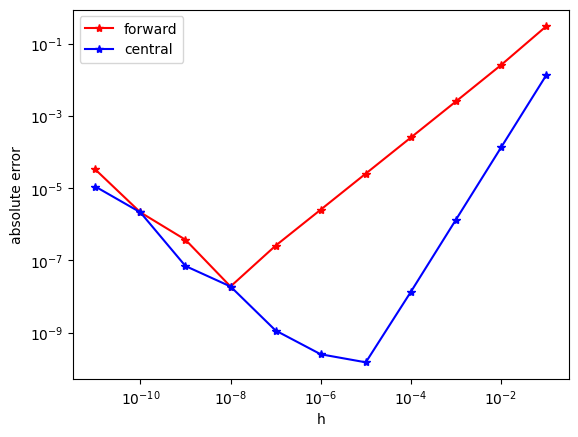

In [42]:
plt.loglog(hs,fds,"r*-",label="forward")
plt.loglog(hs,cds,"b*-",label="central")
plt.xlabel("h")
plt.ylabel("absolute error")
plt.legend();

## Numerical Differentiation with `NumPy`

This method does not take into account the function expression. The only important thing is that the function can be evaluated in the nearby points $x$ and $x+\Delta x$, where $\Delta x$ is sufficiently small. Then $\frac{df}{dx}\approx\frac{f\left(x + \Delta x\right) - f\left(x\right)}{\Delta x}$, which can be called a **numerical approximation** of the derivative. 

Based on that idea there are different approaches for the numerical approximations, which somehow vary in the computation speed and accuracy. However, for all of the methods the results are not accurate - there is a round off error. At this stage there is no need to go into details of various methods, it is enough to investigate one of the numerial differentiation functions, available in `NumPy` package.

You can call function `np.gradient` to find the derivative of function $f\left(x\right) = x^2$ defined above. The first argument is an array of function values, the second defines the spacing $\Delta x$ for the evaluation. Here pass it as an array of $x$ values, the differences will be calculated automatically. You can find the documentation [here](https://numpy.org/doc/stable/reference/generated/numpy.gradient.html).

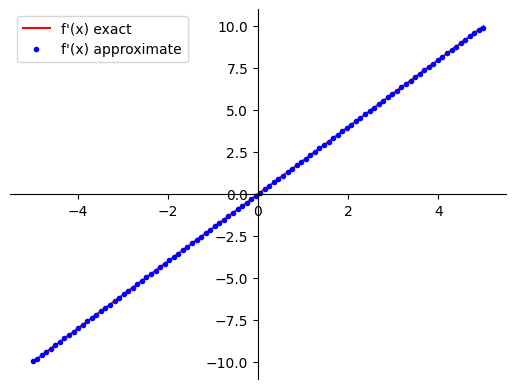

In [26]:
x_array_2 = np.linspace(-5, 5, 100)
dfdx_numerical = np.gradient(f(x_array_2), x_array_2)

plot_f1_and_f2(dfdx_symb_numpy, dfdx_numerical, label1="f'(x) exact", label2="f'(x) approximate")

Try to do numerical differentiation for more complicated function:

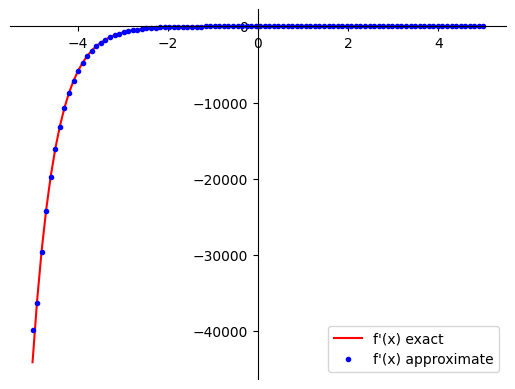

In [27]:
def f_composed(x):
    return np.exp(-2*x) + 3*np.sin(3*x)

plot_f1_and_f2(lambdify(x, dfdx_composed, 'numpy'), np.gradient(f_composed(x_array_2), x_array_2),
              label1="f'(x) exact", label2="f'(x) approximate")

The results are pretty impressive, keeping in mind that it does not matter at all how the function was calculated - only the final values of it!

<a name='3.2'></a>
### 3.2 - Limitations of Numerical Differentiation

Obviously, the first downside of the numerical differentiation is that it is not exact. However, the accuracy of it is normally enough for machine learning applications. At this stage there is no need to evaluate errors of the numerical differentiation.

Another problem is similar to the one which appeared in the symbolic differentiation: it is inaccurate at the points where there are "jumps" of the derivative. Let's compare the exact derivative of the absolute value function and with numerical approximation:

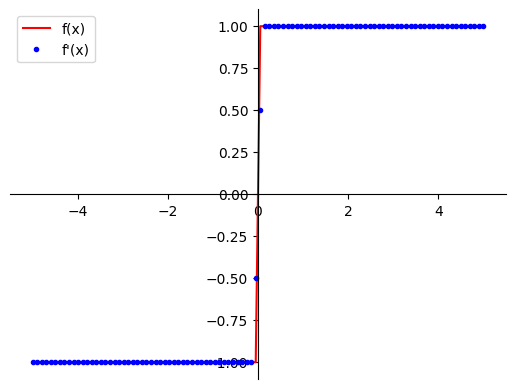

In [28]:
def dfdx_abs(x):
    if x > 0:
        return 1
    else:
        if x < 0:
            return -1
        else:
            return None

plot_f1_and_f2(np.vectorize(dfdx_abs), np.gradient(abs(x_array_2), x_array_2))

You can see that the results near the "jump" are $0.5$ and $-0.5$, while they should be $1$ and $-1$. These cases can give significant errors in the computations.

## Off grid data

In some cases you cannot calculate the function in arbitrary points, but you have a set of arbitrarily placed points in the space with calculated functino values. Can we get the partial derivates along the usual axes?

The answer is yes:
 * For each point select the two closest ones
 * Calculate the gradient with respect to these points
 * Transfer the gradients to the standard basis
Let us see a small example. The potential is $V(\mathbf{r})=r^2$, The gradient $\nabla V =2\mathbf{r}$. For convenience we will always take it at a fixed $z$ value.

In [62]:
def pot(x,y,z):
    return x*x+y*y+z*z
def gradpot(x,y,z):
    r = np.sqrt(x*x+y*y+z*z)
    return np.array([2*x,2*y,2*z])

### Plot the potential

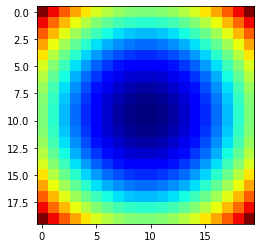

In [221]:
X,Y = np.meshgrid(np.linspace(-1,1,20),np.linspace(-1,1,20))
V = pot(X,Y,0.1)
plt.imshow(V,cmap='jet')

### Plot the gradient at $z=0.1$

<ipython-input-62-4fd3b224ebe8>:5: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray
  return np.array([2*x,2*y,2*z])


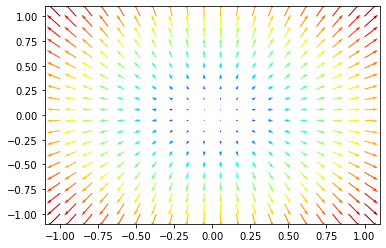

In [86]:
X = X.flatten()
Y = Y.flatten()
graddat=gradpot(X,Y,0.1)
length = np.linalg.norm(graddat,axis=0)/np.linalg.norm(graddat,axis=0).max()
plt.figure()
plt.quiver(X,Y,graddat[0],graddat[1],color=cm.jet(length),scale=50)
plt.show()

### The random $N=1000$ points

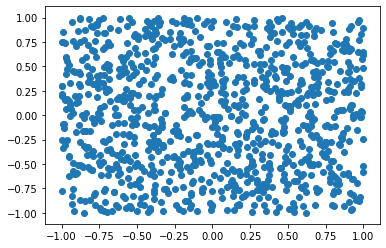

In [124]:
N = 1000
pr = np.random.random((N,2))*2-1
plt.scatter(pr[:,0],pr[:,1])

In [125]:
dm = scipy.spatial.distance_matrix(pr,pr)

### The closest 2 points (we skip the first one as it is the point itself)

In [126]:
dm[5].argsort()[1:3]

array([995, 580])

In [127]:
pr[96]-pr[5]

array([-0.6979287 , -1.23711903])

### Calculate the gradient

In [194]:
z = 0.1
grad = np.zeros((N,2),dtype=float)
for i in range(N):
    neighs = dm[i].argsort()[1:3]
    p1 = pr[neighs[0]]
    p2 = pr[neighs[1]]
    poti = pot(pr[i][0],pr[i][1],z)
    pot1 = pot(p1[0],p1[1],z)
    pot2 = pot(p2[0],p2[1],z)
    dp1 = p1 - pr[i]
    dp2 = p2 - pr[i]
    d1 = pot1 - poti
    d2 = pot2 - poti
    A = np.vstack([dp1,dp2])
    grad[i] = np.dot(np.linalg.inv(A),[d1,d2])

### Plot the gradient at the given points

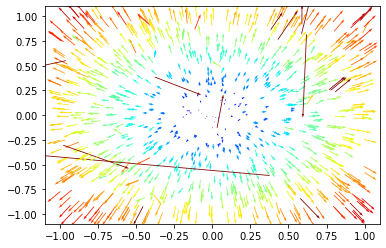

In [200]:
length = np.linalg.norm(grad,axis=1)/np.linalg.norm(graddat,axis=0).max()
plt.figure()
plt.quiver(pr[:,0],pr[:,1],grad[:,0],grad[:,1],color=cm.jet(length),scale=50)
plt.show()

### Observations
 * In general the results are acceptable
 * Large errors due to marginally linearly indepependent vectors

In [215]:
z = 0.1
grad = np.zeros((N,2),dtype=float)
for i in range(N):
    neighs = dm[i].argsort()[1:3]
    p1 = pr[neighs[0]]
    p2 = pr[neighs[1]]
    poti = pot(pr[i][0],pr[i][1],z)
    pot1 = pot(p1[0],p1[1],z)
    pot2 = pot(p2[0],p2[1],z)
    dp1 = p1 - pr[i]
    dp2 = p2 - pr[i]
    d1 = pot1 - poti
    d2 = pot2 - poti
    A = np.vstack([dp1,dp2])
    grad[i] = np.dot(np.linalg.inv(A),[d1,d2])
    if np.linalg.norm(grad[i]-gradpot(pr[i,0],pr[i,1],z)[:2]) > 1.5:
        print(np.cross(dp1,dp2)/np.linalg.norm(dp1)/np.linalg.norm(dp2),\
              np.linalg.norm(grad[i]-gradpot(pr[i,0],pr[i,1],z)[:2]))

-0.011659609965722276 8.416256433206199
-0.016161082727781127 5.285403416022431
-0.04631125535989613 1.5717758109879068
-0.03860273005614073 3.459571193444825
0.020062576929163713 1.6718400698480935
-0.06239470212635175 2.2541464035449015
-0.007156078695144882 1.6718400698481093
-0.0489261828899465 1.9823043731434749
0.00769487710523458 12.13775274554223
0.013155679820994198 6.453222404665881
-0.027216701590034392 1.6718400698480984
0.0001333126726073483 847.0249273887738
0.0035274984758023697 19.57004405384726
0.006168825482746103 14.2053199619871


In [220]:
z = 0.1
grad = np.zeros((N,2),dtype=float)
for i in range(N):
    neighs = dm[i].argsort()[1:3]
    p1 = pr[neighs[0]]
    p2 = pr[neighs[1]]
    poti = pot(pr[i][0],pr[i][1],z)
    pot1 = pot(p1[0],p1[1],z)
    pot2 = pot(p2[0],p2[1],z)
    dp1 = p1 - pr[i]
    dp2 = p2 - pr[i]
    d1 = pot1 - poti
    d2 = pot2 - poti
    A = np.vstack([dp1,dp2])
    grad[i] = np.dot(np.linalg.inv(A),[d1,d2])
    if abs(np.cross(dp1,dp2)/np.linalg.norm(dp1)/np.linalg.norm(dp2)) < 0.02:
        print(np.cross(dp1,dp2)/np.linalg.norm(dp1)/np.linalg.norm(dp2),\
              np.linalg.norm(grad[i]-gradpot(pr[i,0],pr[i,1],z)[:2]))

-0.011659609965722276 8.416256433206199
-0.016161082727781127 5.285403416022431
-0.007156078695144882 1.6718400698481093
0.01348065815186629 0.5318970310365491
0.00769487710523458 12.13775274554223
0.013155679820994198 6.453222404665881
-0.017654217848325014 0.5065713201015226
-0.008023117532970508 0.2802549139062332
0.0001333126726073483 847.0249273887738
0.0035274984758023697 19.57004405384726
0.006168825482746103 14.2053199619871
